In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
sys.path.append('../results')

from PATNs import find_solution
import utils

Optimization terminated successfully. (HiGHS Status 7: Optimal)
Sparsity: 84.6%


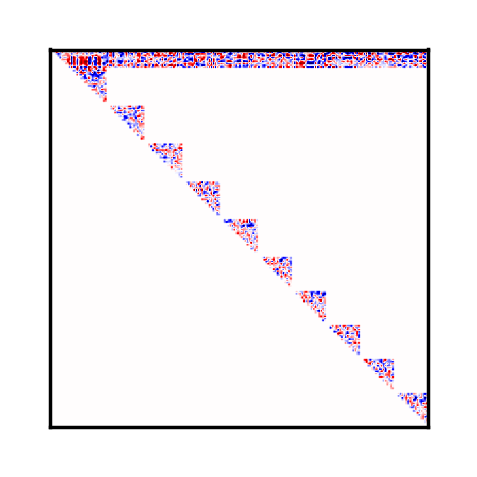

In [94]:
# --- Parameters ---
N           = 200
block_sizes = [21]*5 + [19]*5
maxw        = 3
etoi        = 4                  # 4:1 E:I ratio -> 1/5 inhibitory

n_real_per_block = [0] * 10
coarse_vals      = [0] * 9
#target_cross=[(2, 9), (6, 7)]

result = find_solution(
    N, block_sizes, maxw, etoi,
    n_real_per_block, coarse_vals,
    lam0=0.0,
    real_position='beginning',
    coarse_placement='beginning',
    coupling='between_via_global',
    l1_weights=(1, 0, 0),
    target_cross=None,
    random_cross=None,
    cross_reward=0.1,
    maxw_cross=2,
    seed=16 
)
print('Sparsity: %.1f%%' % (100 * np.mean(np.abs(result['W']) < 1e-8)))

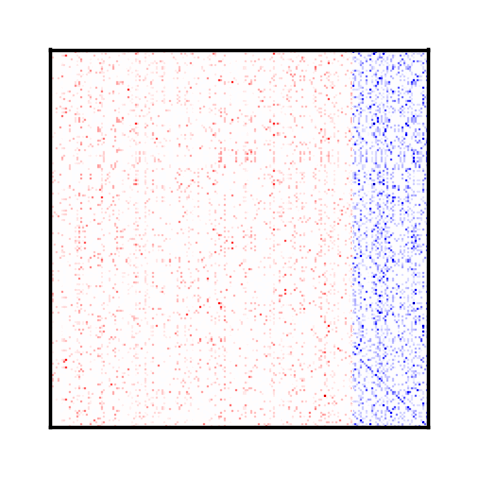

In [95]:
# --- Connectivity matrix W ---
W_J = result['W']

fig, ax = plt.subplots(figsize=(1, 1), dpi=500)

vmax = np.max(np.abs(W_J))
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
ax.imshow(W_J, cmap='seismic', norm=norm)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

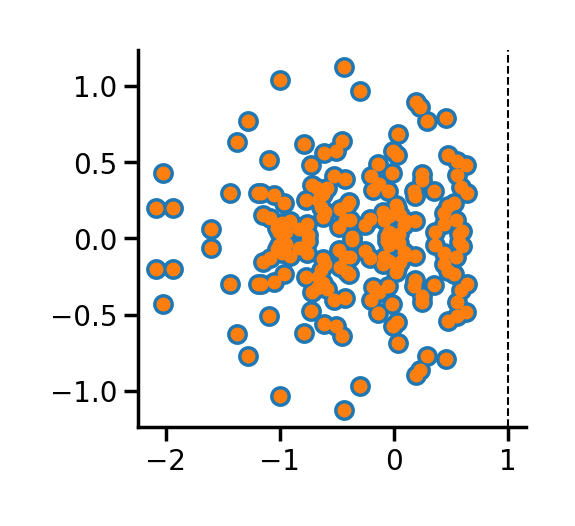

In [96]:
# --- Eigenvalues: realized vs prescribed ---
evals          = np.linalg.eigvals(result['W'])
evals_original = result['Lambda']

fig, ax = plt.subplots(figsize=(1, 1), dpi=500)

ax.plot(evals.real,          evals.imag,          '.', markersize=4, label='realized')
ax.plot(evals_original.real, evals_original.imag, '.', markersize=2, label='prescribed')
ax.axvline(1, color='k', linewidth=0.3, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2, labelsize=4)

plt.show()

In [97]:
# --- Simulation setup ---
T    = 10       # s
dt   = 0.005    # s
tauE = 0.1      # s
tauI = 0.1      # s

a = 1 * np.ones(N)
c = 1 * np.ones(N)
b = 0 * np.ones(N)
bias = np.zeros(N)

J = result['W'].copy()
W, _ = W_from_J(J, a, b, c)
initial_conditions = init_cond(J)

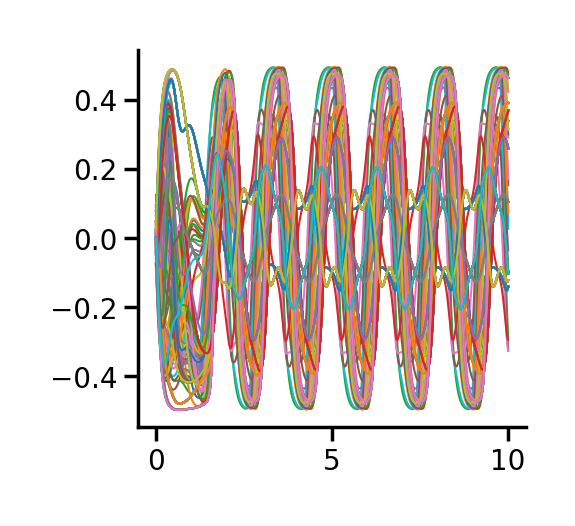

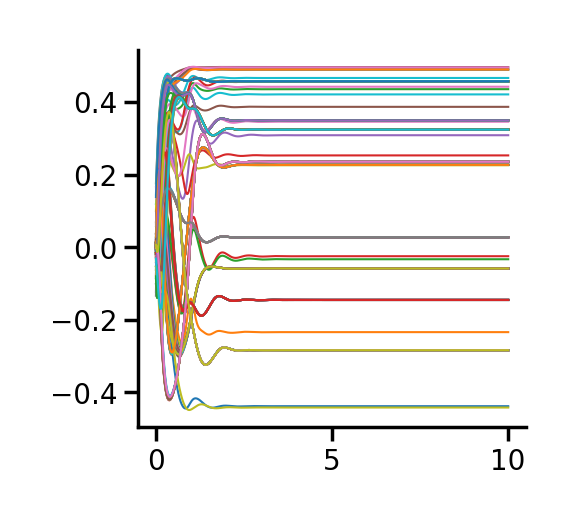

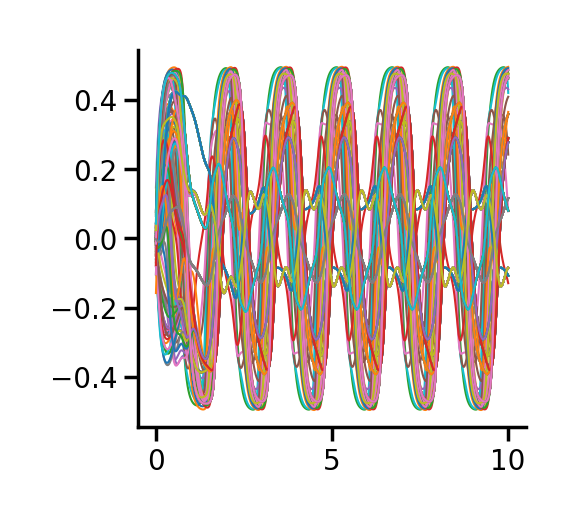

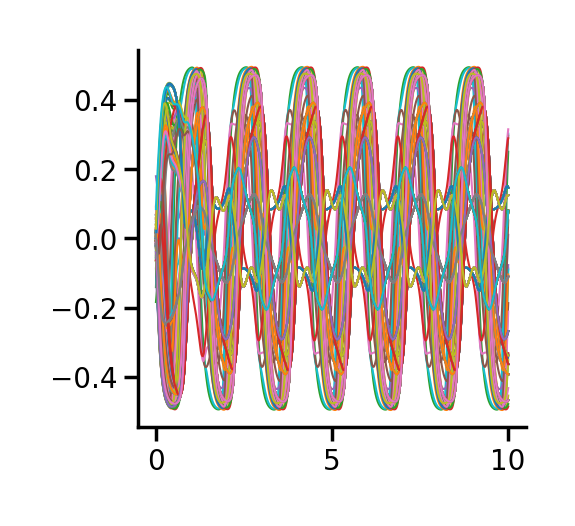

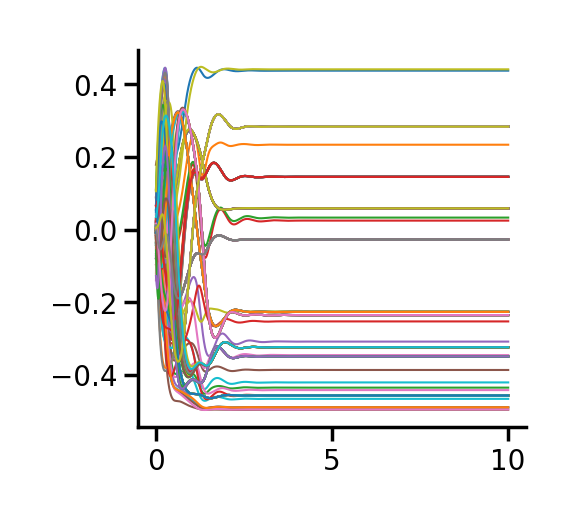

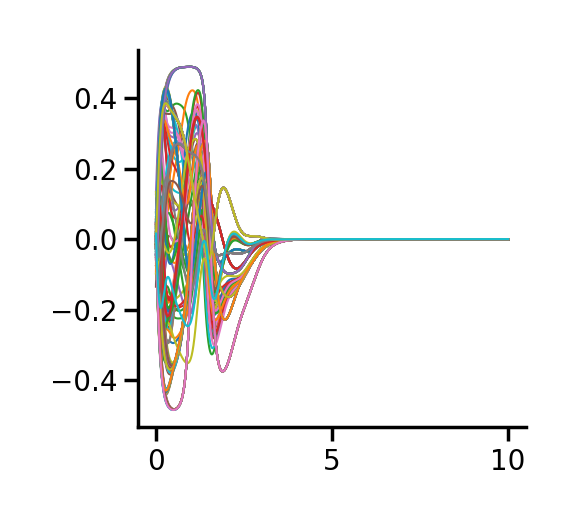

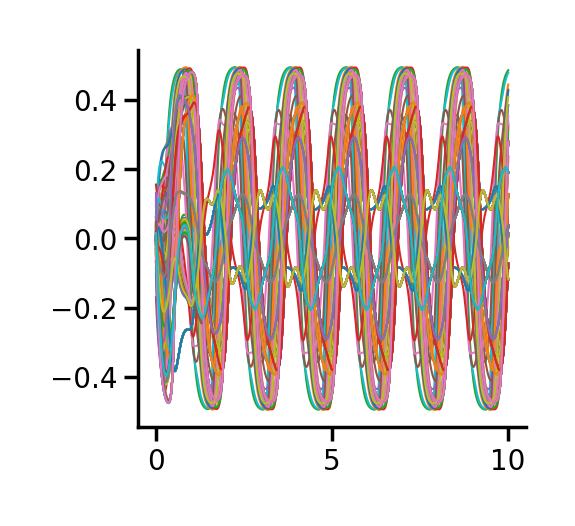

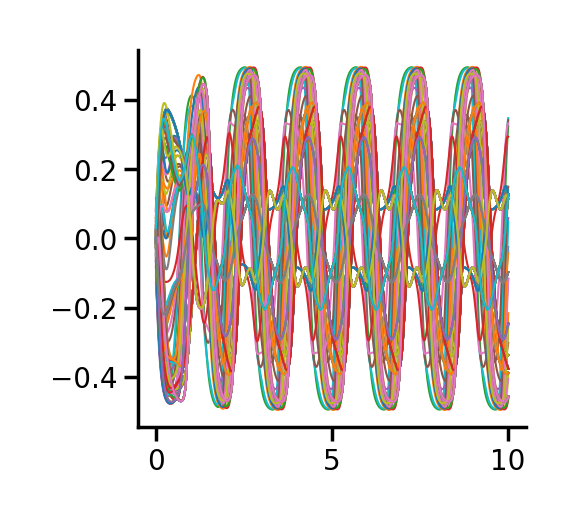

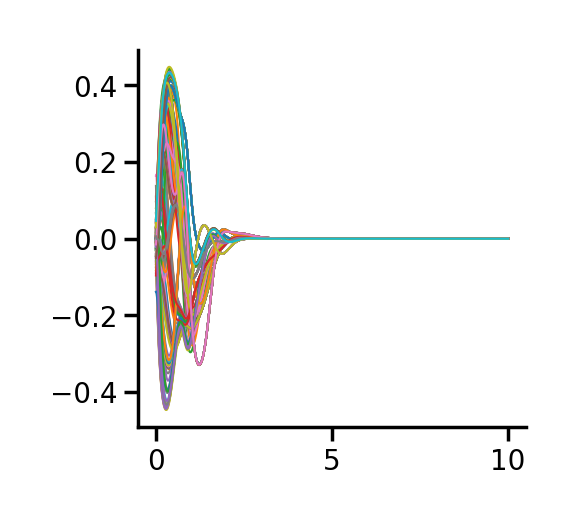

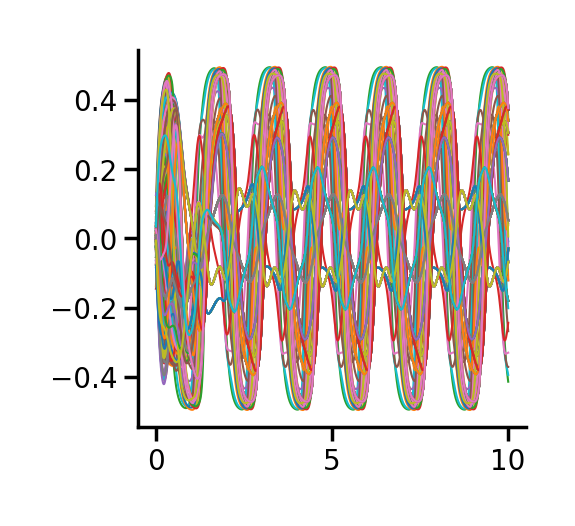

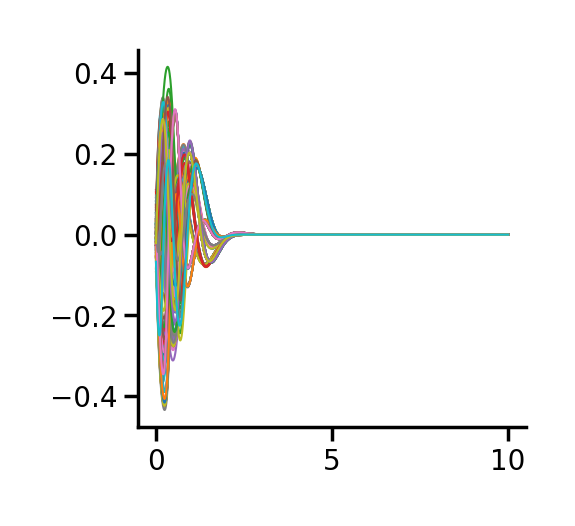

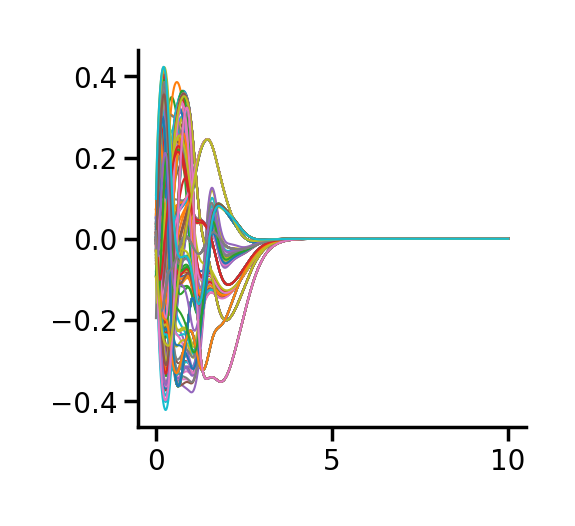

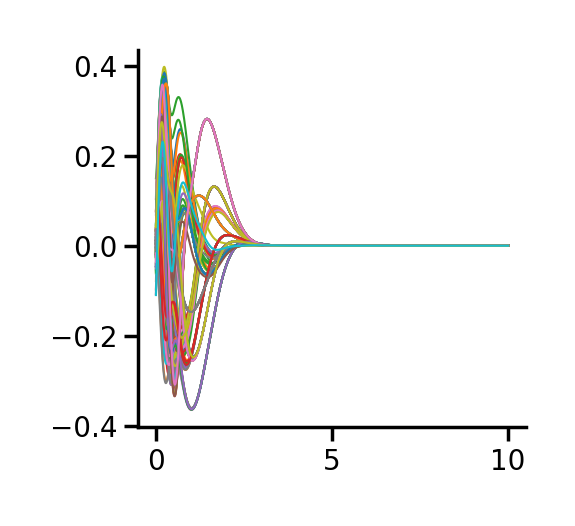

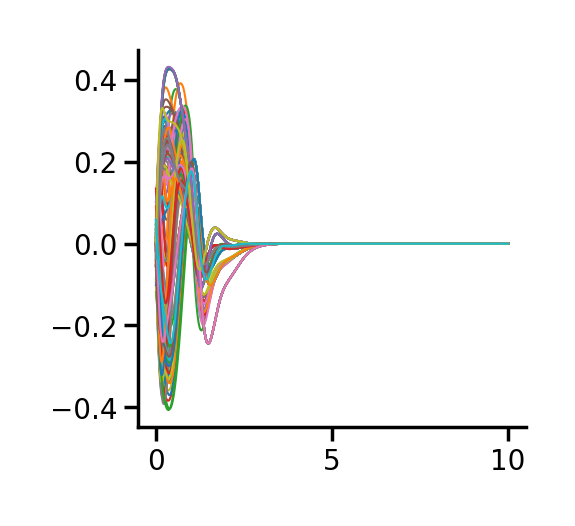

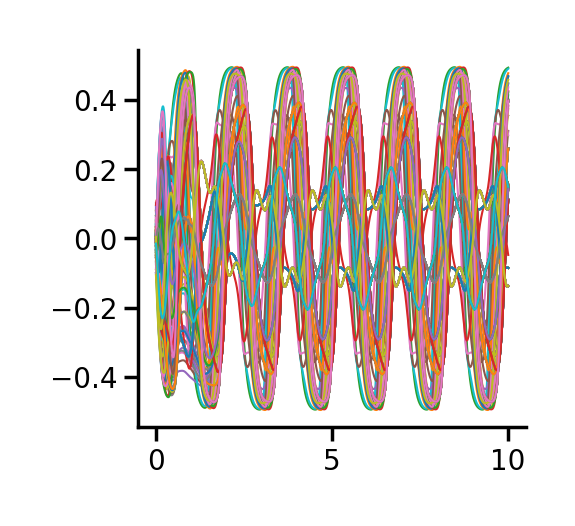

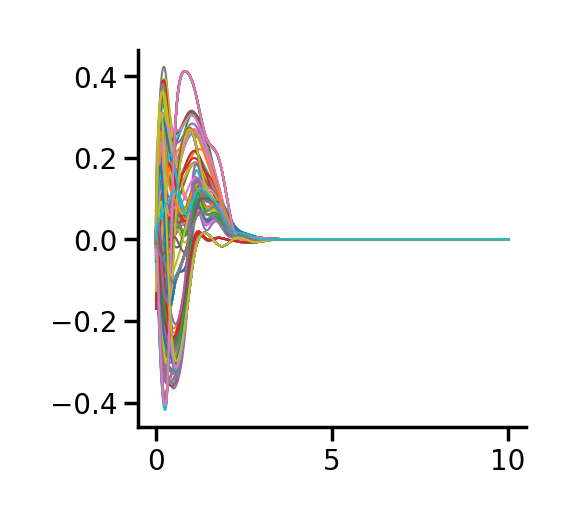

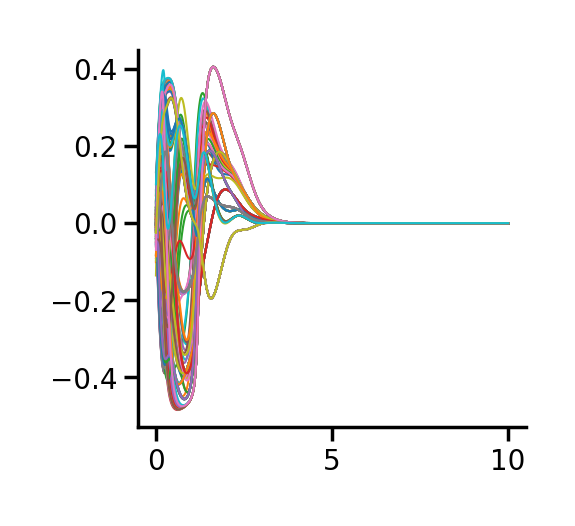

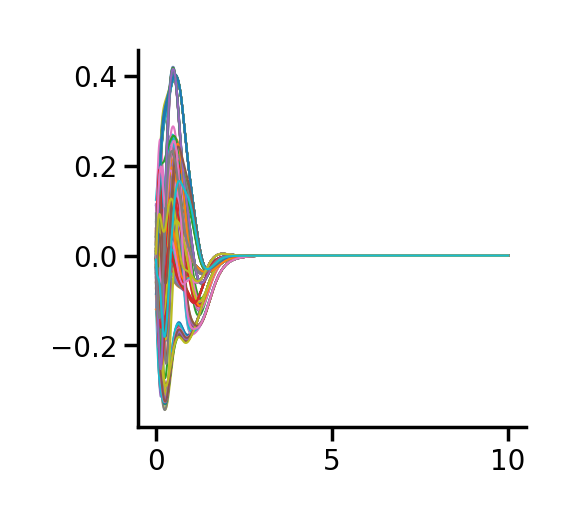

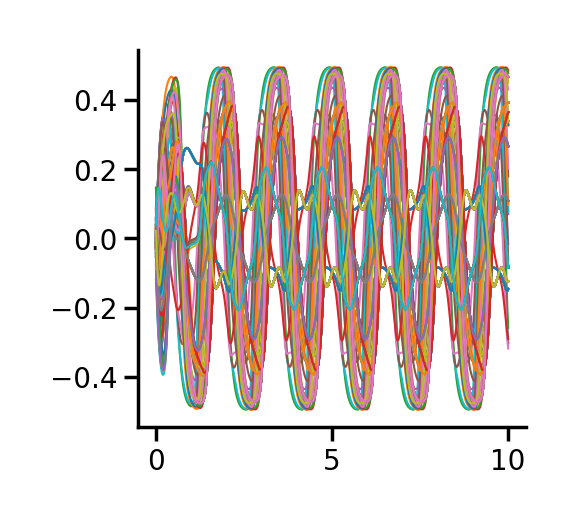

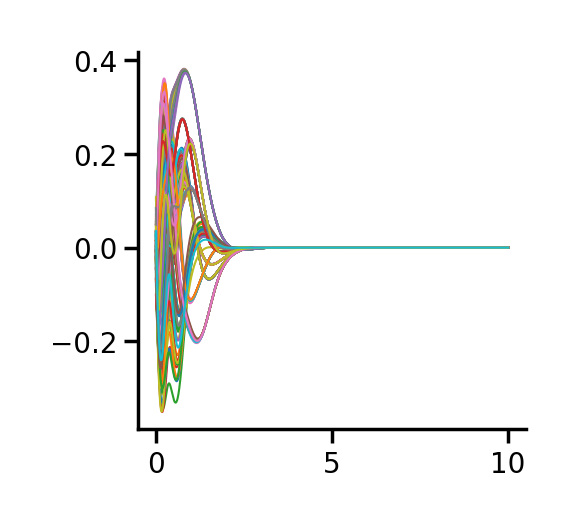

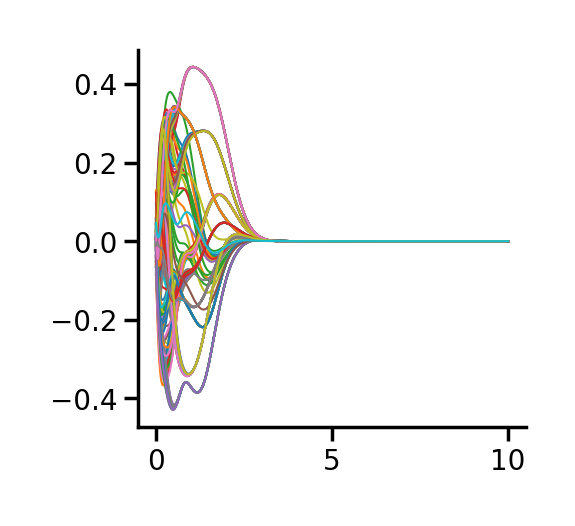

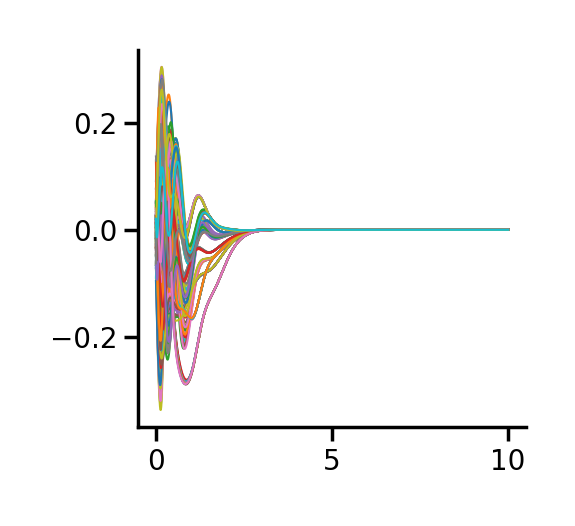

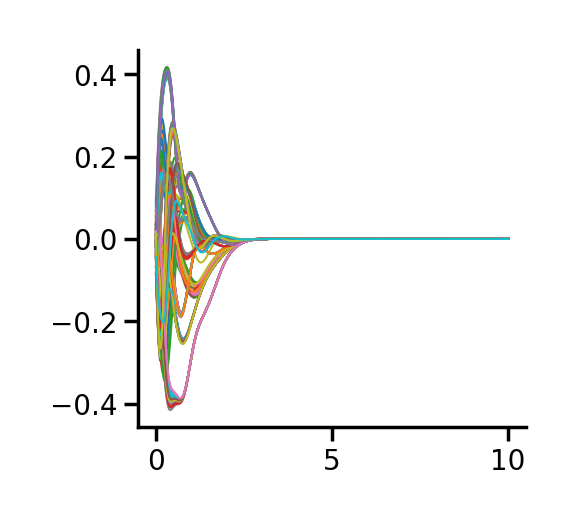

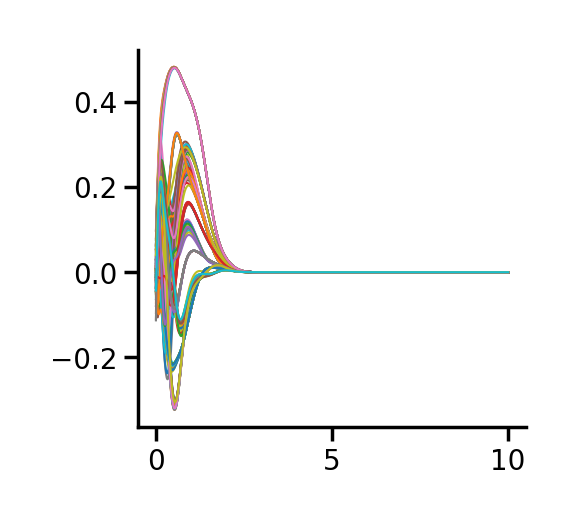

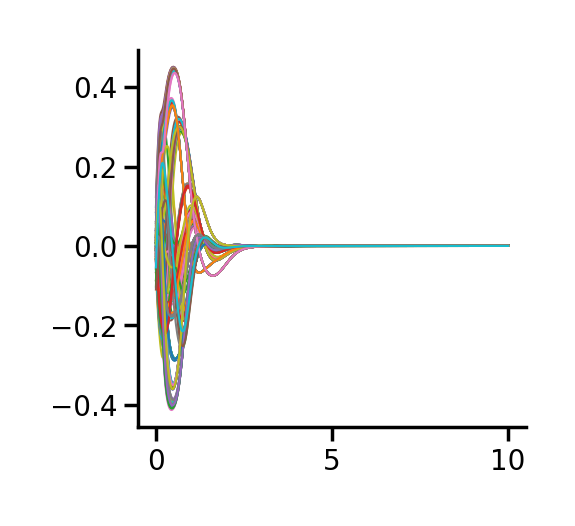

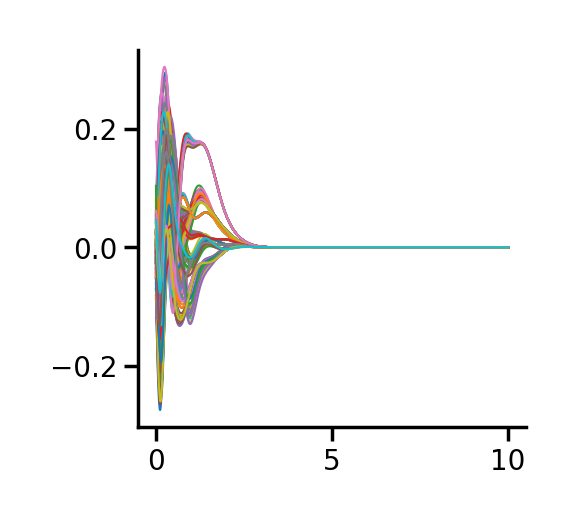

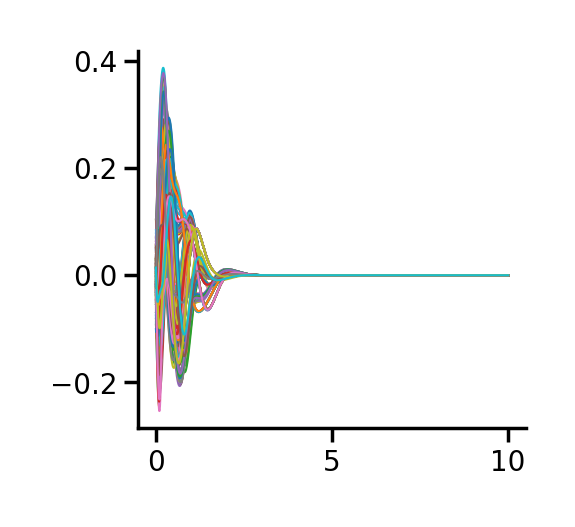

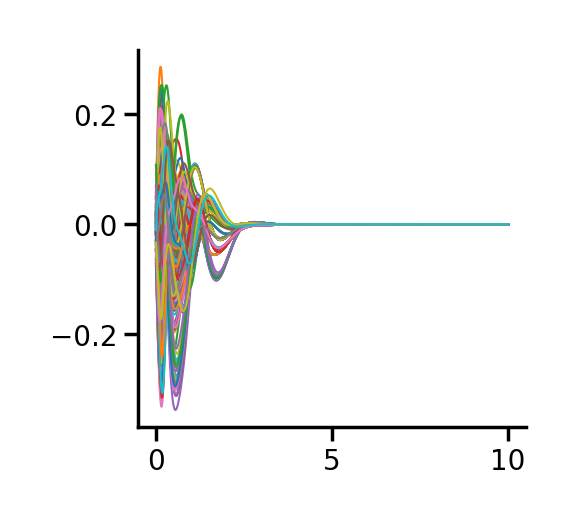

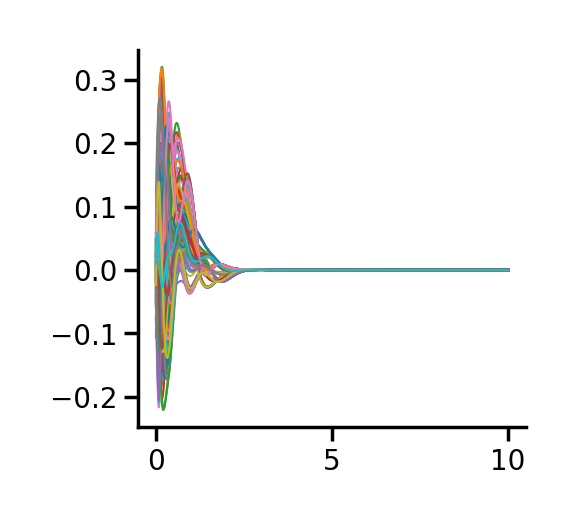

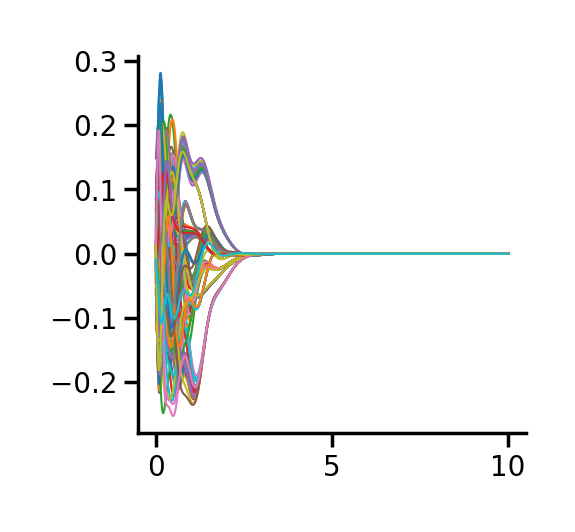

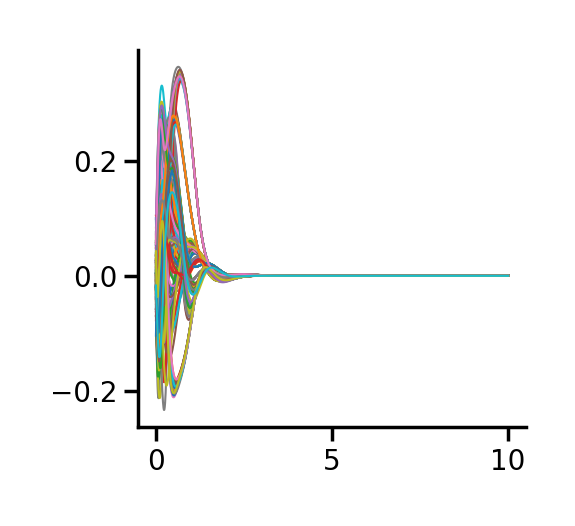

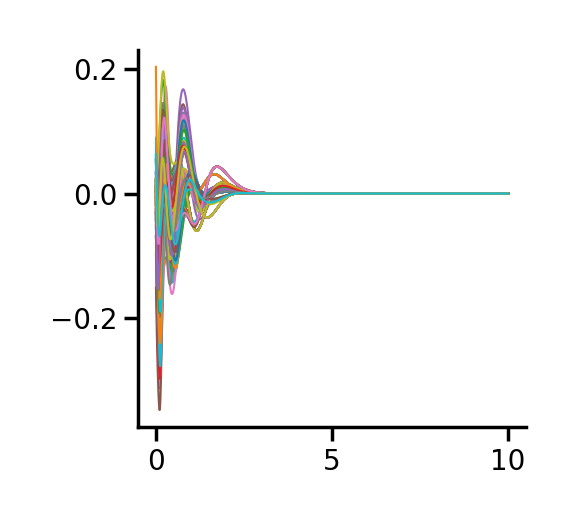

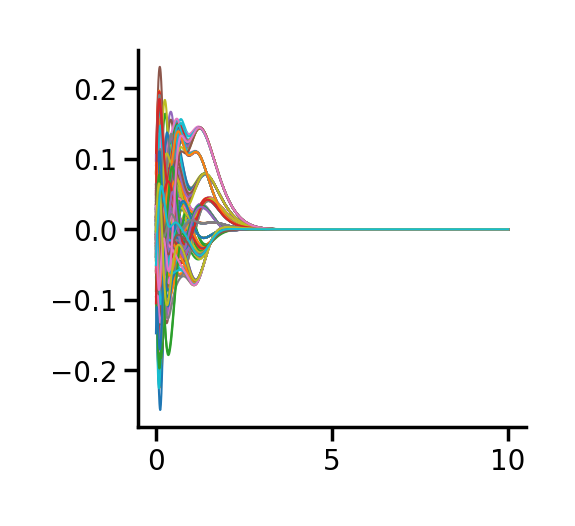

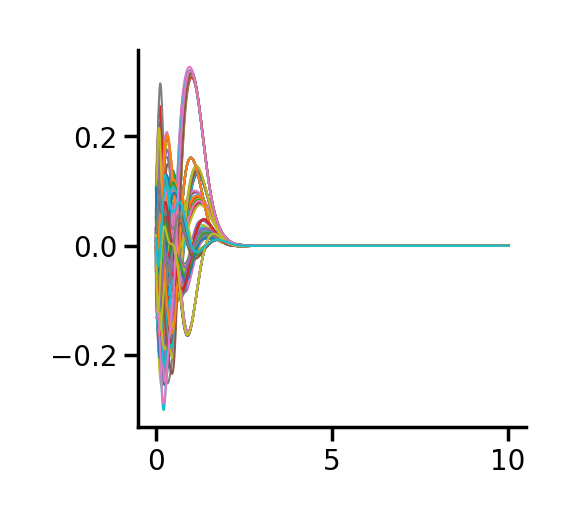

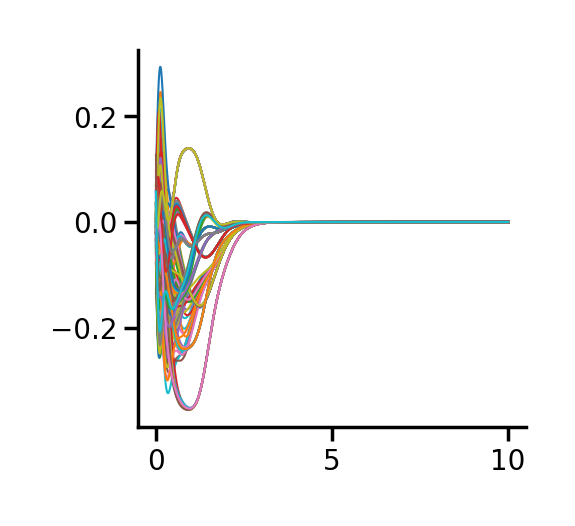

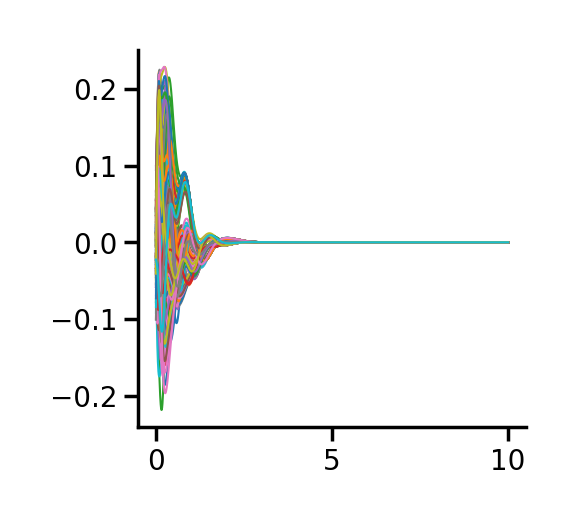

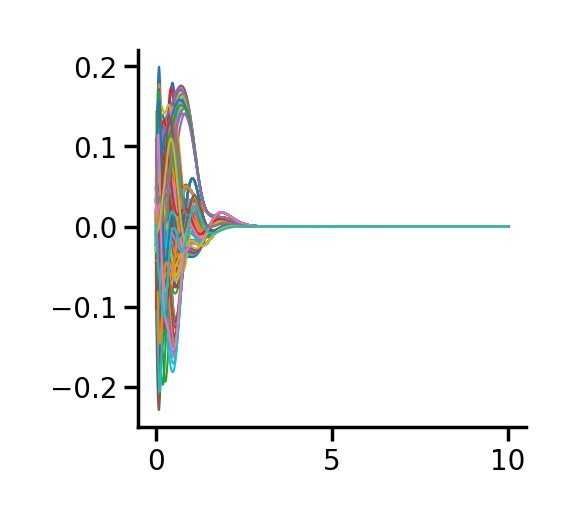

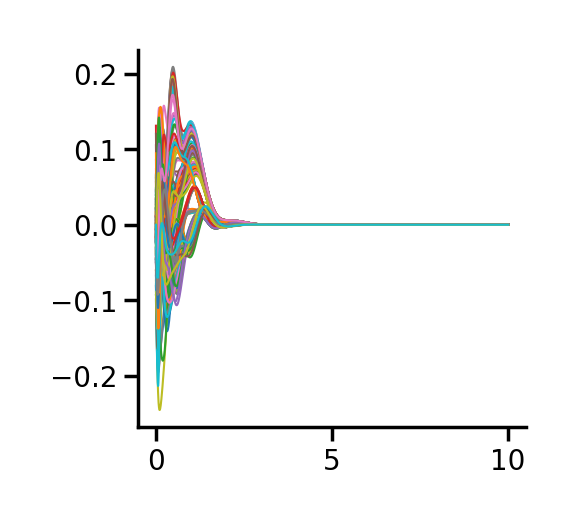

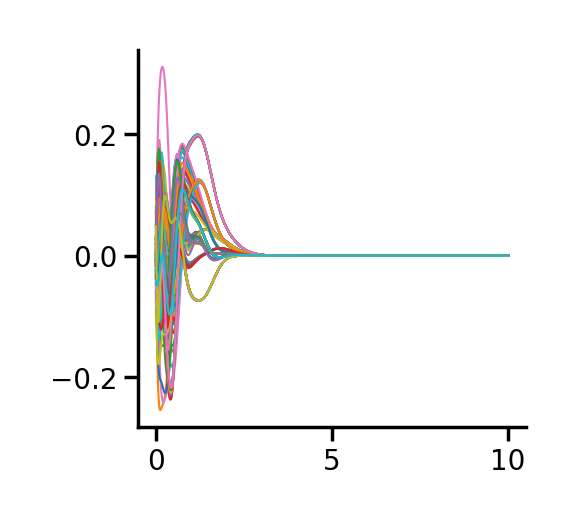

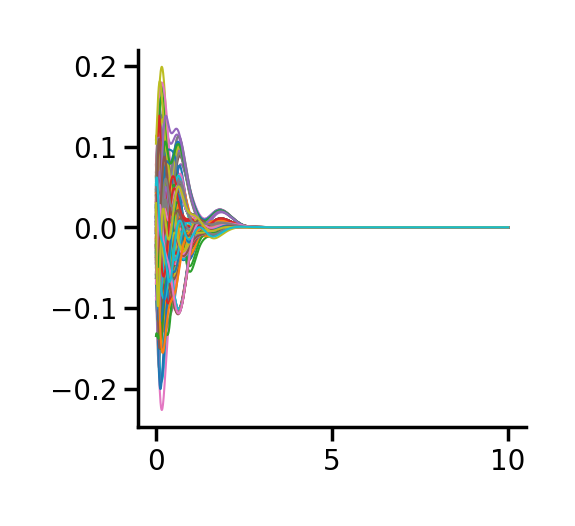

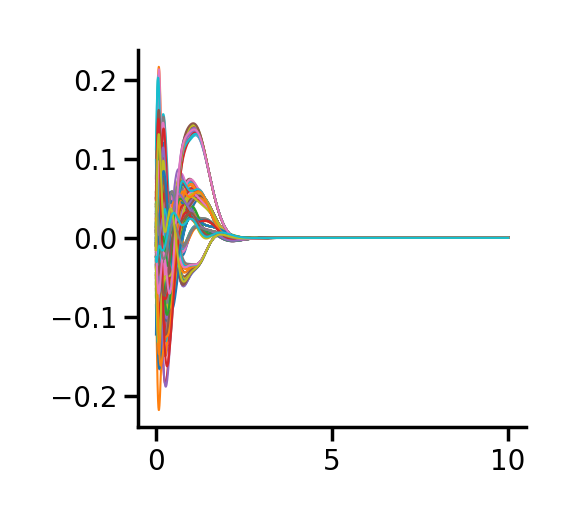

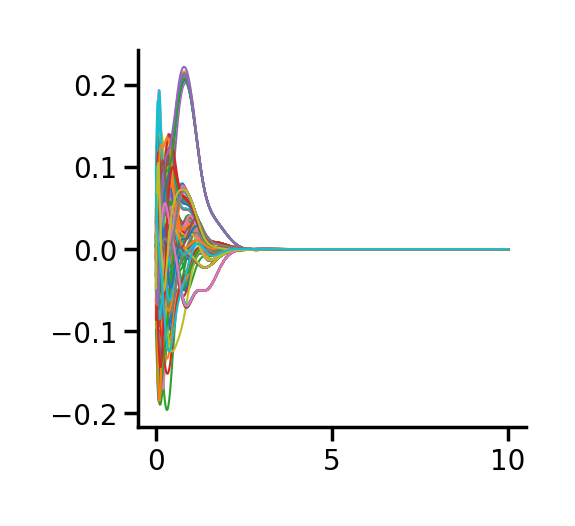

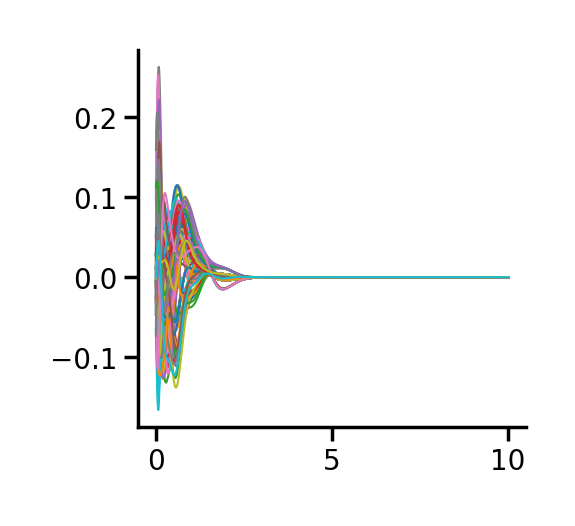

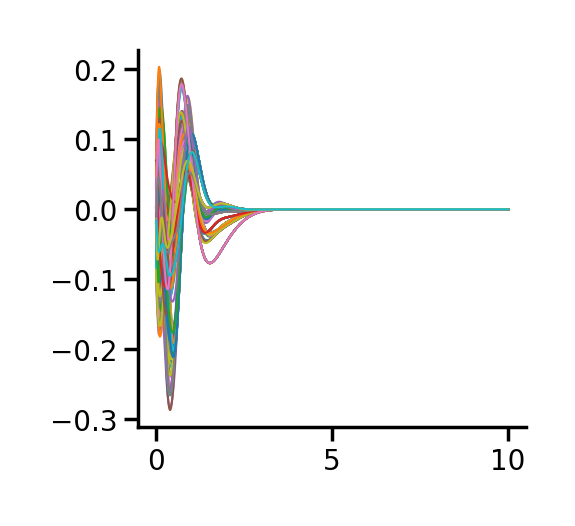

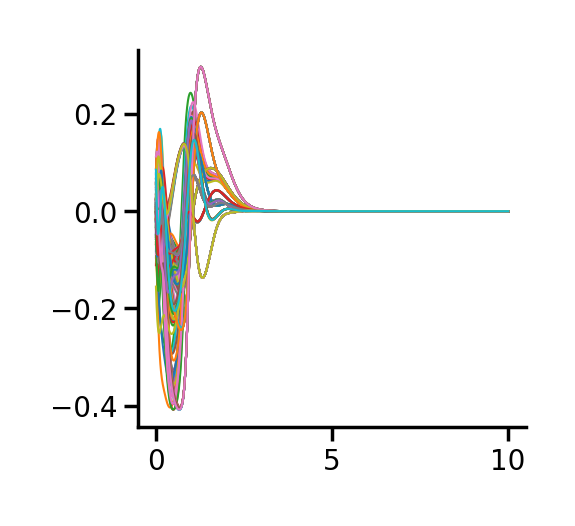

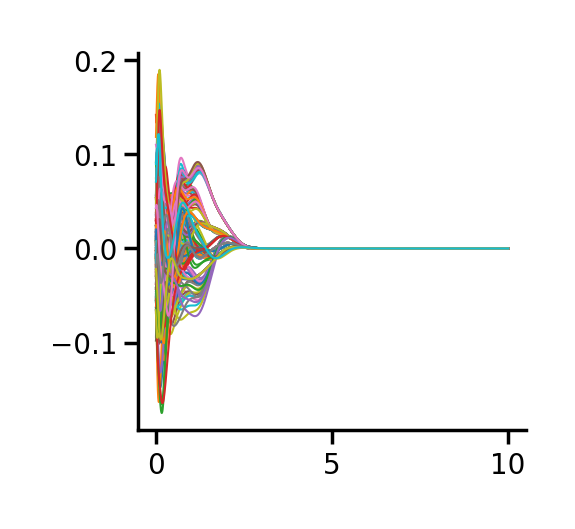

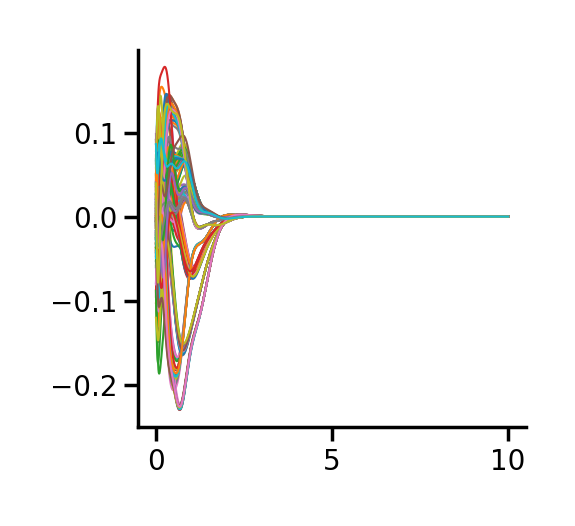

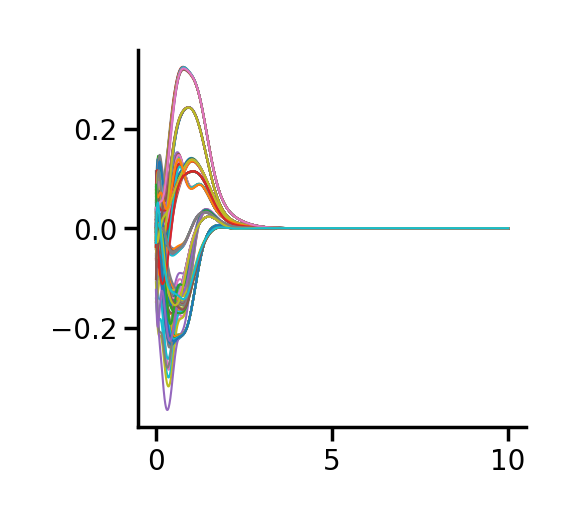

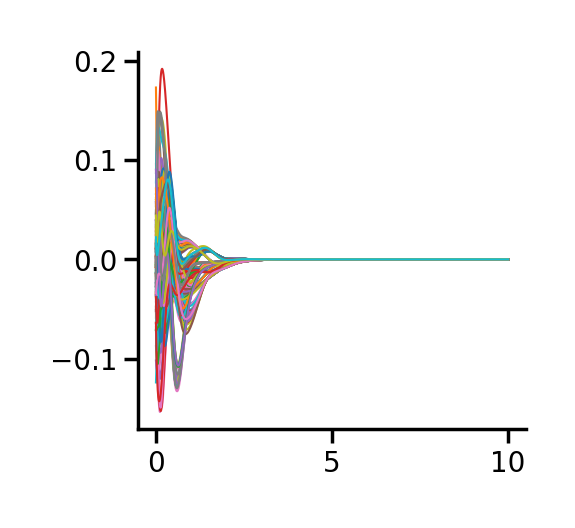

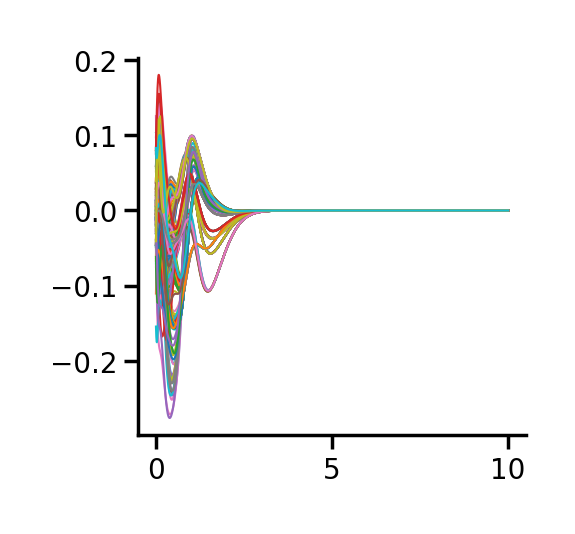

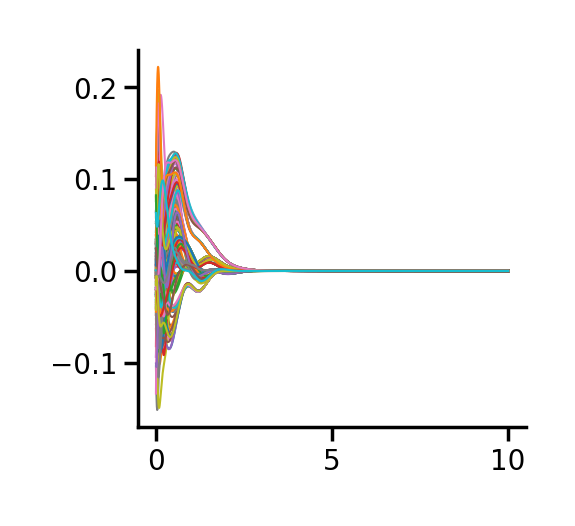

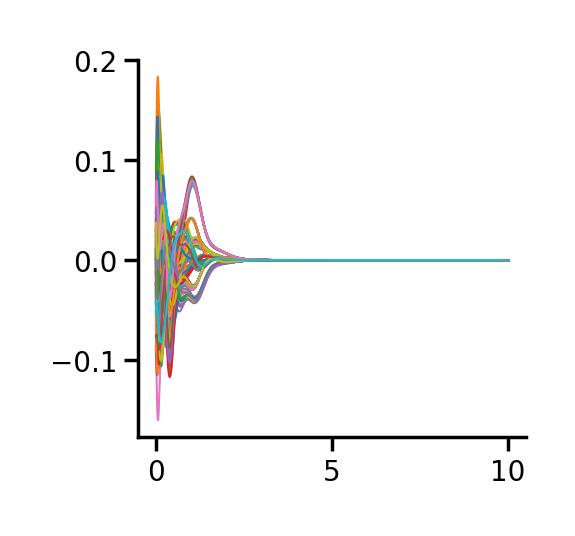

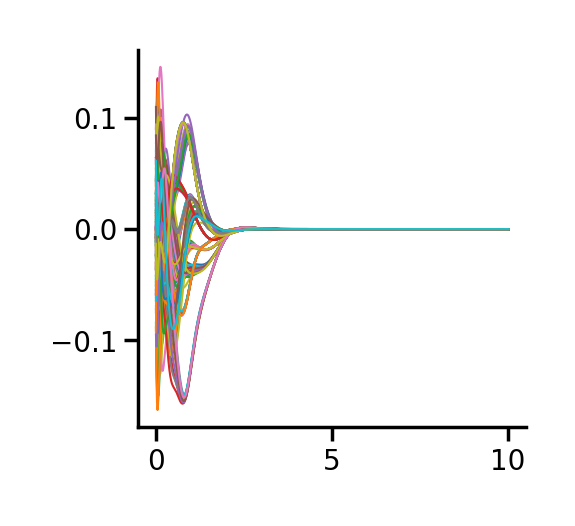

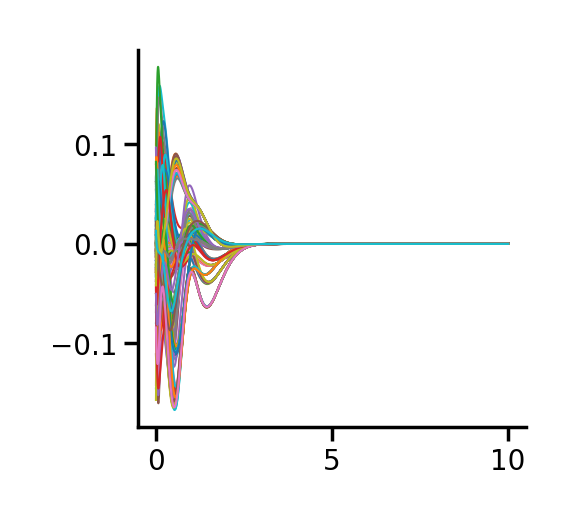

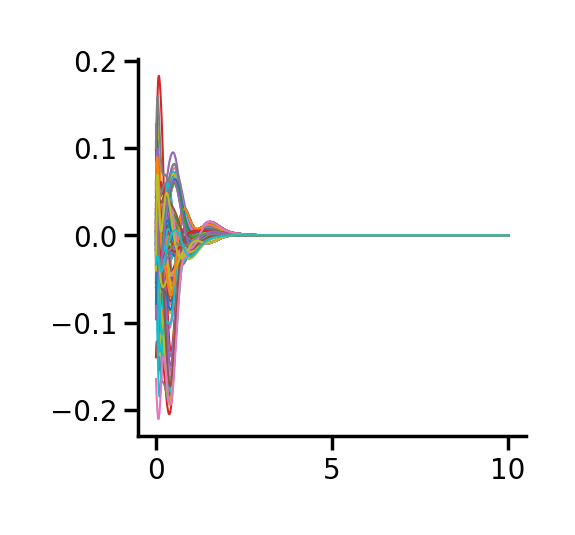

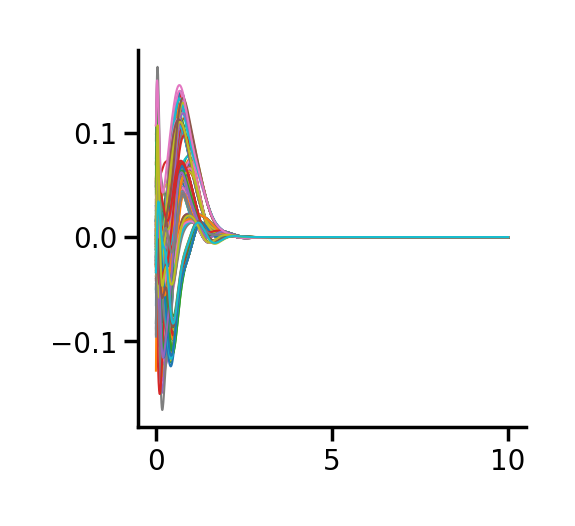

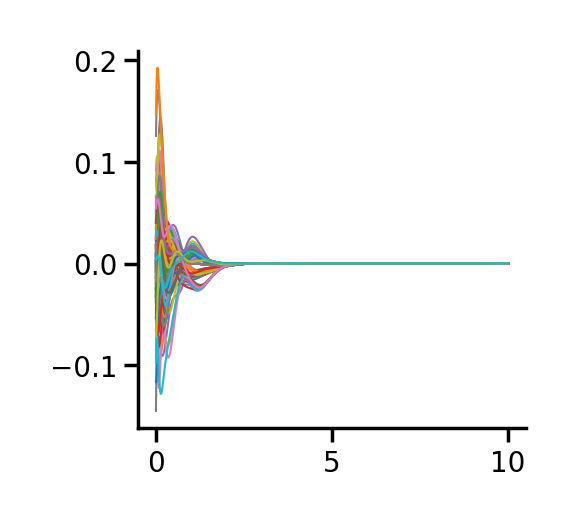

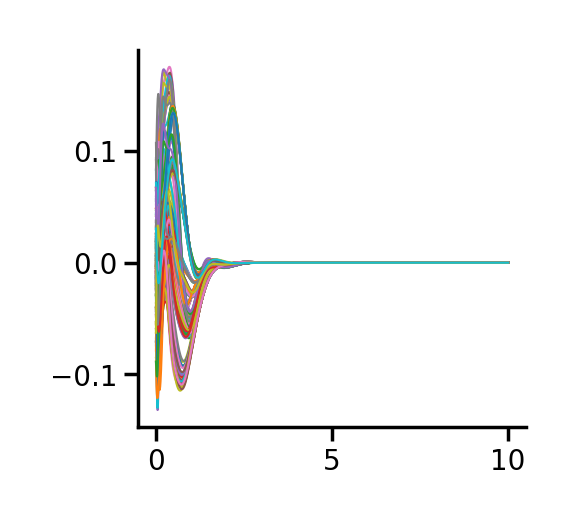

KeyboardInterrupt: 

In [98]:
# --- Dynamics from each initial condition ---
for i in range(100):
    t, r = solve_rk4_springBox(0.5 * initial_conditions[:, i], W, tauE, tauI, T, dt, a, b, c, bias)

    fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
    ax.plot(t, r, linewidth=0.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5, pad=1, length=2, labelsize=4)

    plt.show()